# 5. EVT detection, graph propagation, and GAT source localization

One synthetic event realization is followed through the complete pipeline. The same `GraphTimeSeries` object is used in every panel, so the standalone signal, EVT alarm, propagation map, and GAT prediction all describe the **same event**.


The notebook solves an extreme-event source-localization task on a graph:
An extreme event is observed across several connected time-series channels. Which graph node did the event start from?
This is a node-classification/ranking problem. For each complete event realization, exactly one node is treated as the true source. The GAT produces one score for every candidate node, and the node with the highest probability is the predicted source. The notebook explicitly describes each event realization as one graph example and says that the GAT outputs logits for all possible source nodes.
For 18 nodes, the output is conceptually:

P(source = node 0)
P(source = node 1)
...
P(source = node 17)
The predicted source is:
predicted_source = np.argmax(probabilities)
Why do we use multiple nodes?
A single time series can tell us that something unusual happened, but it usually cannot tell us where the event originated.
With multiple nodes, we can compare:

which node reacted first;
which node had the strongest response;
how the response weakened across the network;
whether neighboring nodes reacted consistently;
whether the observed propagation agrees with the known graph structure.
In the synthetic generator, an event begins at source_node and propagates along graph edges. Nodes farther from the source receive the event later and with lower amplitude. 
Specifically:

arrival = event_onset + 3 * distances
means that every additional graph hop introduces a delay of three time steps, while:
magnitude * np.exp(-0.22 * distances[node])
makes the event weaker with increasing distance from the source. 
This creates the information needed for source localization.

Simple example
Suppose the graph is:
Node 0 ─ Node 1 ─ Node 2 ─ Node 3
If the signals show:
Node 1: strong response at t=850
Node 0: weaker response at t=853
Node 2: weaker response at t=853
Node 3: still weaker response at t=856
then node 1 is a plausible source.
The GAT learns this kind of relationship from the node measurements and graph connections.

Why does every node need a time series?
Each node represents a measurement channel—for example:
an electrode in brain recordings;
a vibration or temperature sensor in an engine;
a financial asset or market sector;
a station in a power grid;
a device in a computer network.
The raw data is therefore:
time × nodes
The repository’s GraphTimeSeries structure explicitly defines values that way. 
In the default example:

1200 time points × 18 nodes
The time series are necessary because source localization depends partly on temporal behavior—especially the order in which nodes react.
Without a time series per node, we would lose information such as:

baseline behavior;
event onset;
response amplitude;
response duration;
response energy;
response slope;
arrival delay.
The two tasks in the complete pipeline
The project actually separates the problem into two components.
Task 1: EVT detection — when did the event occur?
The first task examines the multichannel signals and determines whether an extreme event occurred and at which time.
Conceptually:

Input:  multichannel time series
Output: detected event time
This answers:
When did the extreme event happen?
prepare_sample() first calls the EVT detector on all node signals:
detection = EVTEventDetector(baseline_end).fit_detect(series.values)
EVT is useful here because the event is represented as an unusually large tail observation relative to normal baseline behavior.

Task 2: GAT localization — where did the event originate?
After the event time is detected, the system calculates features for every node and uses the graph neural network to identify the source.
Conceptually:

Input:
    detected event
    node features
    graph connections

Output:
    probability that each node is the source
This answers:
Where did the extreme event start?
The pipeline constructs a GraphSample containing:
node features;
graph edges;
the known source label used during training.
Thus, the complete task is:

Multichannel signals
        │
        ▼
EVT detector
“When did something extreme happen?”
        │
        ▼
Node feature extraction
“How did each node respond?”
        │
        ▼
GAT
“Which node was the source?”
What information is given to the GAT?
The GAT does not directly process all 1,200 time points in this implementation. Instead, the signal around the detected event is summarized into six features for every node:
Peak — maximum standardized deviation.
Energy — average squared standardized signal.
Slope — average signal change.
Latency — how quickly the node crosses an extreme threshold.
Degree — number of graph neighbors.
Neighbor peak — average peak response of adjacent nodes.
These features are constructed in node_features(). 
The resulting GAT input has shape:

18 nodes × 6 features
For example:
Node    Peak  Energy  Slope  Latency  Degree  Neighbor peak
0       7.2    11.4    0.1     0.00      1        6.1
1       6.1     8.3    0.1     0.06      2        5.8
2       5.0     6.2    0.0     0.12      2        4.9
...
17      1.2     1.0    0.0     0.80      1        1.3
A likely source generally has an early, strong response, while surrounding nodes show delayed and attenuated responses.
Why use a GAT rather than an ordinary classifier?
An ordinary classifier could score every node independently. However, that would ignore the fact that the nodes are connected.
A Graph Attention Network uses:

Each node’s own features.
Features of connected neighboring nodes.
Learned attention weights indicating which neighbor relationships are informative.
The model contains two GATv2Conv layers. The first creates a hidden representation from each node and its neighbors; the second produces one source logit per node. 
This matters because source evidence is relational.

For example, a large peak at node 5 could be:

the true event source;
noise affecting only node 5;
a propagated event originating at adjacent node 4.
The response pattern of nodes connected to node 5 helps distinguish these cases. A GAT can learn how much attention to assign to those neighbors.
Why specifically 18 nodes?
There is no theoretical reason that the task must use exactly 18 nodes. It is the default synthetic configuration:
n_nodes: int = 18
n_groups: int = 3
With these defaults, the generator forms three structural groups of six nodes. The graph construction connects nodes within each group and connects consecutive groups. 

Eighteen is useful for the demonstration because it is:

large enough to make localization nontrivial;
small enough to display in one plot;
divisible into three equal structural groups;
computationally inexpensive.
But the same conceptual task could use:
8 sensors;
64 EEG electrodes;
100 industrial components;
hundreds of financial assets.
The number of nodes should normally correspond to the number of real measurement channels.
What is the training label?
For every generated event realization, the label is one integer:
source_node
For example:
Example 1 → source node 0
Example 2 → source node 1
Example 3 → source node 2
The model produces a logit for each node. Cross-entropy compares those logits with the known source-node index. 
Therefore, this is not:

time-series forecasting;
graph classification;
edge prediction;
detection of 18 independent events.
It is:
Node-level source classification within each event graph.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from evt_demo import generate_graph_time_series, train_gat_with_trace
from evt_demo.pipeline import prepare_sample

# Each realization is one graph-level training example.  Keep the raw series,
# detection result, and GAT sample aligned instead of generating unrelated data.
realizations = [
    generate_graph_time_series(source_node=i, seed=100 + i)
    for i in range(6)
]
prepared = [prepare_sample(series) for series in realizations]
samples = [sample for sample, _ in prepared]
detections = [detection for _, detection in prepared]

trace = train_gat_with_trace(samples, epochs=20, seed=42)
raw_data = realizations[0]
sample = samples[0]
detection = detections[0]

n_nodes, n_features = sample.features.shape
actual_source = int(sample.source_node)
probabilities = np.asarray(trace.probabilities)
predicted_source = int(np.argmax(probabilities))

print(f"Raw series: {raw_data.values.shape} = time × nodes")
print(f"GAT input: {sample.features.shape} = nodes × engineered features")
print(f"EVT detected at t={detection.detected_at}; true onset t={raw_data.event_onset}")
print(f"Actual source={actual_source}; predicted source={predicted_source}")


/root/.pyenv/versions/3.14.4/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Raw series: (1200, 18) = time × nodes
GAT input: (18, 6) = nodes × engineered features
EVT detected at t=854; true onset t=850
Actual source=0; predicted source=0


## One event, three connected tasks

1. **EVT detection — when?** The standalone source-channel view provides intuition, while the graph-level EVT indicator aggregates the strongest standardized node deviations. The GPD threshold and persistence rule determine the alarm time.
2. **Graph propagation — how?** The heatmap shows the event moving from the source to neighboring nodes. The black line is the known synthetic arrival front.
3. **GAT localization — where?** Six causal features per node are passed along graph edges. The GAT assigns a source probability to every node; attention is encoded by edge width and color.

The full raw time series is used for EVT detection. The GAT does **not** receive all time points directly: `prepare_sample` converts the detected event window into a `nodes × features` matrix.


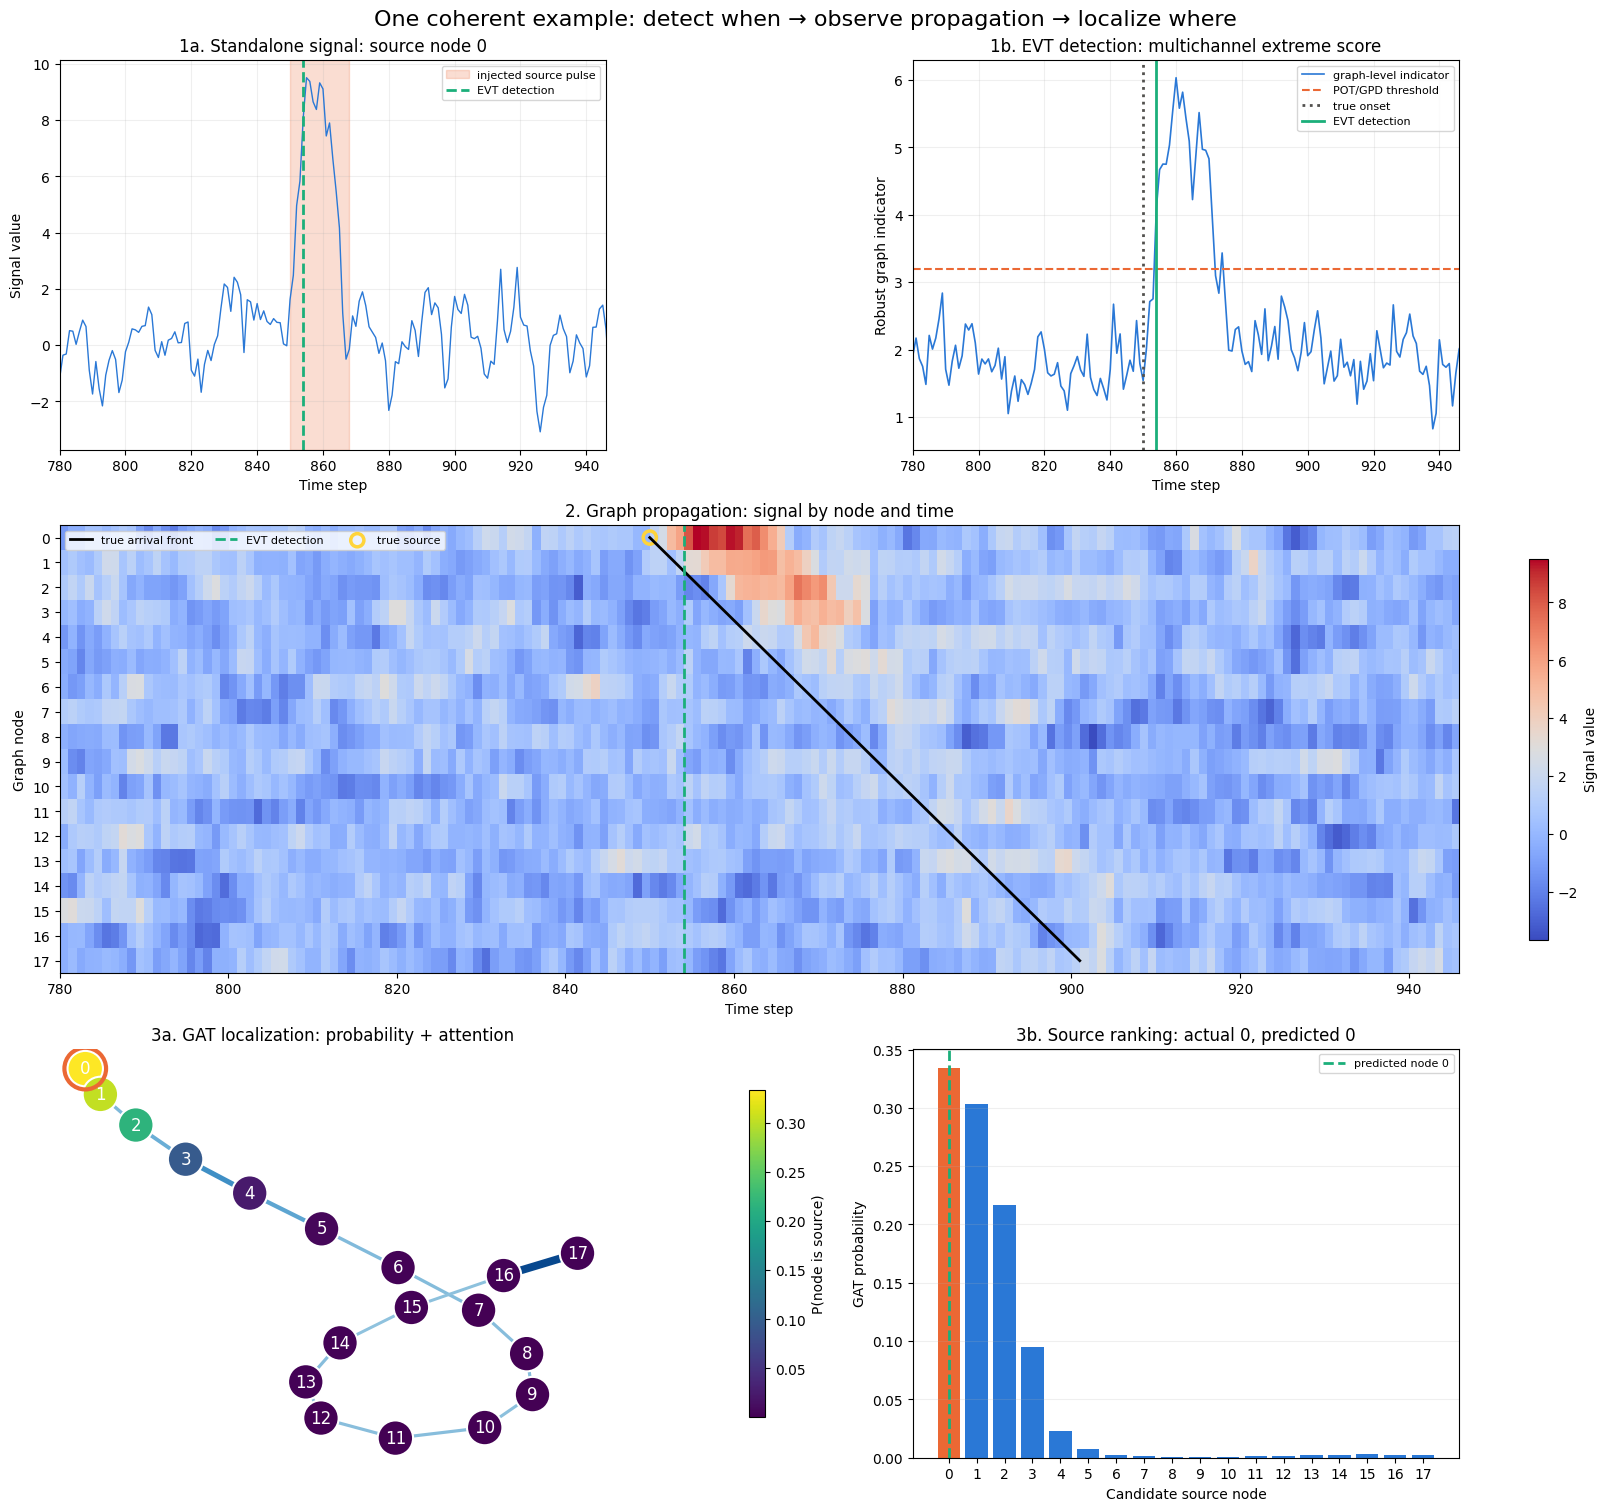

In [3]:
# Build the graph once so propagation and localization use identical topology.
graph = nx.from_numpy_array(raw_data.adjacency)
positions = nx.spring_layout(graph, seed=42)

# Last-layer attention, excluding the self-loops added internally by GATv2.
attention = {}
for (left, right), weight in zip(
    trace.attention_edge_index.T, trace.attention_weights
):
    left, right = int(left), int(right)
    if left != right:
        attention[(left, right)] = float(weight)
attention_values = np.asarray(list(attention.values()))
attention_min = float(attention_values.min()) if attention_values.size else 0.0
attention_span = max(float(np.ptp(attention_values)), 1e-8)

# Focus the raw-signal panels around the injected event, but retain enough
# pre-event context to see that the EVT alarm is not a baseline fluctuation.
view_start = raw_data.event_onset - 70
view_stop = min(len(raw_data.values), int(raw_data.arrival_times.max()) + 45)
time = np.arange(len(raw_data.values))
source_arrival = int(raw_data.arrival_times[actual_source])
source_stop = min(source_arrival + 18, len(raw_data.values))

fig = plt.figure(figsize=(16, 15), constrained_layout=True)
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1.15, 1.05])
ax_series = fig.add_subplot(grid[0, 0])
ax_evt = fig.add_subplot(grid[0, 1])
ax_heatmap = fig.add_subplot(grid[1, :])
ax_graph = fig.add_subplot(grid[2, 0])
ax_scores = fig.add_subplot(grid[2, 1])

# 1a. Standalone view of a real channel from this graph realization.
ax_series.plot(time, raw_data.values[:, actual_source], color="#2a78d6", lw=1)
ax_series.axvspan(
    source_arrival, source_stop, color="#eb6834", alpha=0.22,
    label="injected source pulse",
)
ax_series.axvline(
    detection.detected_at, color="#1baf7a", ls="--", lw=2,
    label="EVT detection",
)
ax_series.set_xlim(view_start, view_stop)
ax_series.set(
    title=f"1a. Standalone signal: source node {actual_source}",
    xlabel="Time step", ylabel="Signal value",
)
ax_series.legend(fontsize=8)
ax_series.grid(alpha=0.2)

# 1b. The actual multichannel statistic to which EVT is applied.
ax_evt.plot(time, detection.indicator, color="#2a78d6", lw=1.2,
            label="graph-level indicator")
ax_evt.axhline(detection.threshold, color="#eb6834", ls="--",
               label="POT/GPD threshold")
ax_evt.axvline(raw_data.event_onset, color="#52514e", ls=":", lw=2,
               label="true onset")
ax_evt.axvline(detection.detected_at, color="#1baf7a", lw=2,
               label="EVT detection")
ax_evt.set_xlim(view_start, view_stop)
ax_evt.set(
    title="1b. EVT detection: multichannel extreme score",
    xlabel="Time step", ylabel="Robust graph indicator",
)
ax_evt.legend(fontsize=8)
ax_evt.grid(alpha=0.2)

# 2. Propagation through nodes in the same realization.
image = ax_heatmap.imshow(
    raw_data.values[view_start:view_stop].T,
    aspect="auto", cmap="coolwarm",
    extent=[view_start, view_stop, n_nodes - 0.5, -0.5],
)
ax_heatmap.plot(raw_data.arrival_times, np.arange(n_nodes), color="black", lw=2,
                label="true arrival front")
ax_heatmap.axvline(detection.detected_at, color="#1baf7a", ls="--", lw=2,
                   label="EVT detection")
ax_heatmap.scatter(source_arrival, actual_source, s=90, facecolors="none",
                   edgecolors="#ffd43b", linewidths=2.5, label="true source")
ax_heatmap.set(
    title="2. Graph propagation: signal by node and time",
    xlabel="Time step", ylabel="Graph node",
    yticks=np.arange(n_nodes),
)
ax_heatmap.legend(loc="upper left", fontsize=8, ncol=3)
fig.colorbar(image, ax=ax_heatmap, label="Signal value", shrink=0.85)

# 3a. GAT localization: probabilities on nodes and learned attention on edges.
for left, right in graph.edges():
    directed = [attention.get((left, right)), attention.get((right, left))]
    weight = max(value for value in directed if value is not None)
    normalized = (weight - attention_min) / attention_span
    nx.draw_networkx_edges(
        graph, positions, edgelist=[(left, right)], ax=ax_graph,
        width=1 + 5 * normalized,
        edge_color=[plt.cm.Blues(0.25 + 0.7 * normalized)],
    )
prob_norm = Normalize(vmin=float(probabilities.min()),
                      vmax=float(probabilities.max()) + 1e-12)
nodes = nx.draw_networkx_nodes(
    graph, positions, ax=ax_graph, node_color=probabilities,
    cmap="viridis", vmin=prob_norm.vmin, vmax=prob_norm.vmax,
    node_size=650, edgecolors="white", linewidths=1.5,
)
nx.draw_networkx_labels(graph, positions, ax=ax_graph, font_color="white")
nx.draw_networkx_nodes(
    graph, positions, nodelist=[actual_source], ax=ax_graph,
    node_size=900, node_color="none", edgecolors="#eb6834", linewidths=3,
)
if predicted_source != actual_source:
    nx.draw_networkx_nodes(
        graph, positions, nodelist=[predicted_source], ax=ax_graph,
        node_size=1050, node_color="none", edgecolors="#2a78d6",
        linewidths=2.5, node_shape="s",
    )
fig.colorbar(nodes, ax=ax_graph, label="P(node is source)", shrink=0.8)
ax_graph.set_title("3a. GAT localization: probability + attention")
ax_graph.axis("off")

# 3b. Make the final decision and correctness explicit.
colors = ["#2a78d6"] * n_nodes
colors[actual_source] = "#eb6834"
ax_scores.bar(np.arange(n_nodes), probabilities, color=colors)
ax_scores.axvline(predicted_source, color="#1baf7a", ls="--", lw=2,
                  label=f"predicted node {predicted_source}")
ax_scores.set(
    title=f"3b. Source ranking: actual {actual_source}, predicted {predicted_source}",
    xlabel="Candidate source node", ylabel="GAT probability",
    xticks=np.arange(n_nodes),
)
ax_scores.legend(fontsize=8)
ax_scores.grid(axis="y", alpha=0.2)

fig.suptitle(
    "One coherent example: detect when → observe propagation → localize where",
    fontsize=16,
)
plt.show()


### How to read the result

- The **standalone series** is only a human-readable view of the true source channel. EVT is fitted to the **graph-level indicator** beside it, not to that one line.
- The propagation heatmap and black arrival front explain why time series are needed at every node: onset becomes later and the pulse becomes weaker with graph distance.
- The GAT consumes the extracted node features and graph edges, then ranks all 18 nodes. An orange outline/bar marks the known source; a green dashed line marks the prediction.

This notebook uses six realizations to keep training fast and visually explain the mechanism. A performance study should use many independent realizations for every possible source and event-level cross-validation.
